In [25]:
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import pylab
import numpy as np

weeklies = pd.read_csv("weeklies.txt")
t_test = stats.ttest_rel(weeklies.current, weeklies.lastyear)

t_test.confidence_interval(confidence_level= 0.9)

ConfidenceInterval(low=np.float64(-19.431690236237465), high=np.float64(-0.6472571321835918))

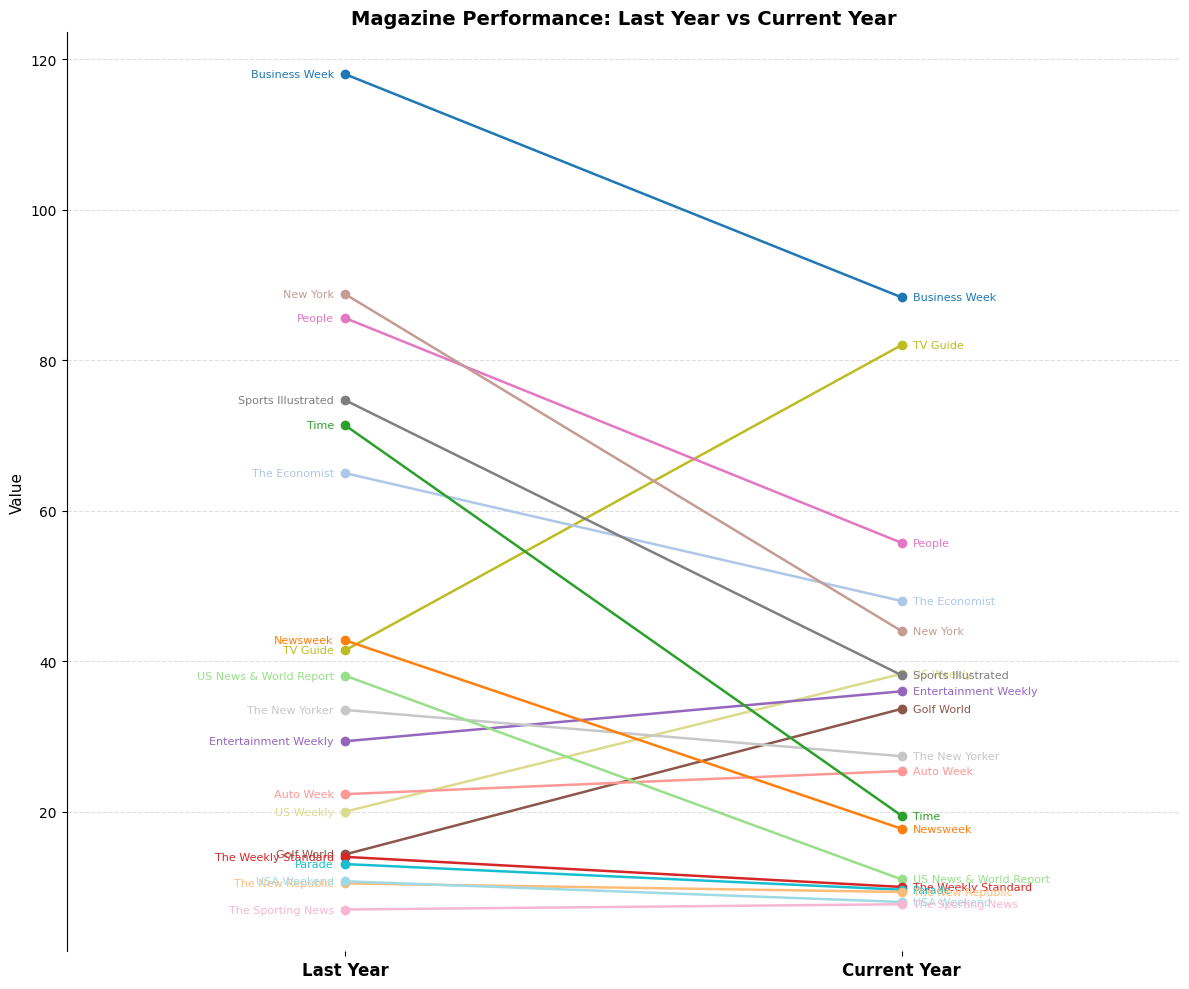

In [32]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Your data inline (or keep your csv read)
weeklies = pd.read_csv("weeklies.txt")

# Sort by current year for cleaner visualization
weeklies = weeklies.sort_values('current', ascending=False)
fig, ax = plt.subplots(figsize=(12, 10))

# Generate a distinct color for each magazine
colors = cm.tab20(np.linspace(0, 1, len(weeklies)))

for i, row in weeklies.iterrows():
    color = colors[i]
    ax.plot([0, 1], [row['lastyear'], row['current']],
            marker='o', linewidth=1.8, color=color, markersize=6)

    # Labels on the left (last year)
    ax.text(-0.02, row['lastyear'], row['magazine'],
            ha='right', va='center', fontsize=8, color=color)

    # Labels on the right (current year)
    ax.text(1.02, row['current'], row['magazine'],
            ha='left', va='center', fontsize=8, color=color)

# Axis formatting
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Last Year', 'Current Year'], fontsize=12, fontweight='bold')
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Magazine Performance: Last Year vs Current Year', fontsize=14, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('magazines_slope.png', dpi=150)
plt.show()

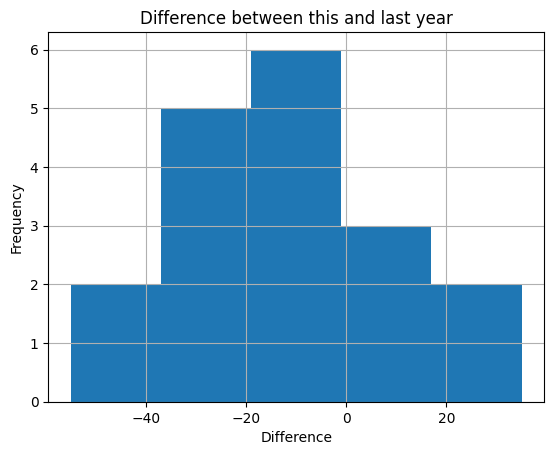

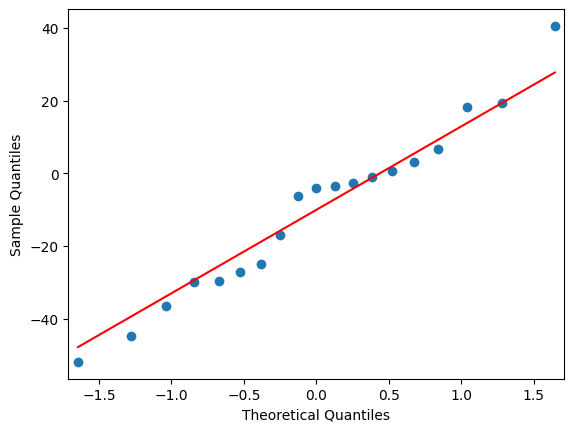

In [27]:
diff_vec = weeklies.current - weeklies.lastyear
ax = diff_vec.hist(bins=range(-55,45,18))

ax.set_title("Difference between this and last year")
ax.set_xlabel("Difference")
ax.set_ylabel("Frequency")

sm.qqplot(diff_vec, line="s")
pylab.show()

In [28]:
stats.shapiro(diff_vec)


ShapiroResult(statistic=np.float64(0.9742276177351654), pvalue=np.float64(0.8566515877322362))

In [29]:
import numpy as np
def skewness(data):
    mean = data.mean()
    top = np.pow(data - mean, 3).mean()
    bottom = np.pow(np.pow(data - mean, 2).mean(), 1.5)
    return top / bottom

skewness(diff_vec)

np.float64(0.12838147993895702)

In [30]:
def kurt(data):
    mean = data.mean()
    top = np.pow(data - mean, 4).mean()
    bottom = np.pow(np.pow(data - mean, 2).mean(), 2)
    return (top / bottom) - 3

kurt(diff_vec)

np.float64(-0.44019517057378854)

In [31]:
def kim_and_white(data):
    quantile = np.quantile(data, [0.25, 0.5, 0.75])
    return ((quantile[2] + quantile[0]) - 2 * quantile[1]) / (quantile[2] - quantile[0])

kim_and_white(diff_vec)

np.float64(-0.6108358110340271)